In [23]:
import pandas as pd

# Convertendo o link de edição para um link de exportação CSV
sheet_id = '1w7vBNjmeu3v327z5Kp664H6Tuc4J2fkS_aZAN6vmccw'
csv_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

try:
    df = pd.read_csv(csv_url)
    print("Dados carregados com sucesso via CSV (sem necessidade de login)!")
    display(df.head())
except Exception as e:
    print(f"Erro ao carregar: {e}. Certifique-se de que a planilha está configurada como 'Qualquer pessoa com o link' pode ler.")

Dados carregados com sucesso via CSV (sem necessidade de login)!


,Carimbo de data/hora,Você ficou gripado no ano passado ?,Você tomou vacina da gripe no ano passado?,"Você frequentou no ano passado, semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)",Você viajou no ano passado mais de 100 km de distância?,"Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?",Quantas horas você dormiu em média por noite no ano passado?,Você praticou atividade física no ano passado?,Você se alimentou de forma balanceada no ano passado?,"Em média, quantas vezes você lavou as mãos por dia no ano passado?","Na sua percepção, o seu nível de estresse no ano passado foi:"
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


### 1. Preparar os Dados para a Árvore de Decisão

Primeiro, precisamos identificar as colunas que representam os 'hábitos' (features) e a coluna que indica se a pessoa 'ficou gripada' (target).

**Atenção**: As colunas `habit_1`, `habit_2`, `habit_3` e `got_flu` são exemplos. Você precisará substituí-las pelos nomes reais das colunas no seu DataFrame `df`.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Identificar as colunas reais
# A coluna alvo baseada no head() anterior parece ser 'Você ficou gripado no ano passado ?'
target_col = 'Você ficou gripado no ano passado ?'

# As colunas de hábitos são todas as outras, exceto o carimbo de data e o alvo
feature_cols_raw = [col for col in df.columns if col not in ['Carimbo de data/hora', target_col]]

# 2. Converter dados categóricos (Texto para Número)
# Árvores de decisão no sklearn precisam de entradas numéricas.
# Usaremos pd.get_dummies para transformar respostas como 'Sim'/'Não' em 0 e 1.
X = pd.get_dummies(df[feature_cols_raw], drop_first=True)
y = df[target_col].map({'Sim': 1, 'Não': 0}) # Mapeando o alvo para binário

# Caso o mapeamento do alvo falhe por causa de caracteres especiais, usamos factorize
if y.isnull().any():
    y, _ = pd.factorize(df[target_col])

# Atualizamos feature_cols para a visualização da árvore
feature_cols = X.columns.tolist()

print("Colunas de entrada (X) preparadas:")
display(X.head())
print("\nValores do Alvo (y) preparados:")
print(y.head())

Colunas de entrada (X) preparadas:


,"Na sua percepção, o seu nível de estresse no ano passado foi:",Você tomou vacina da gripe no ano passado?_Sim,"Você frequentou no ano passado, semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.) _Sim",Você viajou no ano passado mais de 100 km de distância? _Pelo menos uma vez por mês,Você viajou no ano passado mais de 100 km de distância? _Poucas vezes por ano,"Você tem alergia nas vias aéreas (rinite, sinusite, etc.)? _Médio","Você tem alergia nas vias aéreas (rinite, sinusite, etc.)? _Não","Você tem alergia nas vias aéreas (rinite, sinusite, etc.)? _Pouco",Quantas horas você dormiu em média por noite no ano passado?_entre 4 e 6 horas,Quantas horas você dormiu em média por noite no ano passado?_mais de 6 horas,Você praticou atividade física no ano passado?_Sim,"Você se alimentou de forma balanceada no ano passado?_Sim, a maior parte do tempo",Você se alimentou de forma balanceada no ano passado?_Às vezes,"Em média, quantas vezes você lavou as mãos por dia no ano passado?_3 a 5 vezes","Em média, quantas vezes você lavou as mãos por dia no ano passado?_6 a 10 vezes","Em média, quantas vezes você lavou as mãos por dia no ano passado?_Mais de 10 vezes"
0,5.0,True,True,False,True,True,False,False,False,False,True,False,True,True,False,False
1,3.0,True,True,False,False,False,True,False,True,False,False,False,False,False,False,True
2,3.0,False,True,False,True,False,False,True,False,True,True,False,True,False,True,False
3,2.0,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False
4,4.0,True,True,True,False,True,False,False,True,False,False,False,True,False,True,False



Valores do Alvo (y) preparados:
0    1
1    1
2    1
3    1
4    1
Name: Você ficou gripado no ano passado ?, dtype: int64


### 2. Dividir os Dados

Vamos dividir os dados em conjuntos de treinamento e teste para que possamos avaliar o desempenho do modelo em dados que ele nunca viu antes.

In [25]:
# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamanho do conjunto de treinamento: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

Tamanho do conjunto de treinamento: 130 amostras
Tamanho do conjunto de teste: 56 amostras


In [26]:
from sklearn.model_selection import GridSearchCV

# 1. Definir parâmetros para testar (Tuning)
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Usar o GridSearchCV para encontrar a melhor combinação de parâmetros
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 3. Melhor modelo encontrado
best_dtc = grid_search.best_estimator_

print(f"Melhores parâmetros: {grid_search.best_params_}")

# Avaliar o novo modelo
y_pred_opt = best_dtc.predict(X_test)
print(f"Nova Acurácia: {accuracy_score(y_test, y_pred_opt):.2f}")
print("\nRelatório Otimizado:")
print(classification_report(y_test, y_pred_opt))

Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Nova Acurácia: 0.62

Relatório Otimizado:
              precision    recall  f1-score   support

           0       0.52      0.55      0.53        22
           1       0.70      0.68      0.69        34

    accuracy                           0.62        56
   macro avg       0.61      0.61      0.61        56
weighted avg       0.63      0.62      0.63        56



### 3. Treinar o Modelo de Árvore de Decisão

Agora, vamos criar e treinar o classificador de árvore de decisão.

In [27]:
# Criar o objeto classificador de Árvore de Decisão
dtc = DecisionTreeClassifier(random_state=42)

# Treinar o modelo
dtc.fit(X_train, y_train)

print("Modelo de Árvore de Decisão treinado com sucesso!")

Modelo de Árvore de Decisão treinado com sucesso!


### 4. Avaliar o Modelo

Vamos usar o conjunto de teste para ver quão bem o nosso modelo se comporta.

In [28]:
# Fazer previsões no conjunto de teste
y_pred = dtc.predict(X_test)

# Avaliar o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia do modelo: {accuracy:.2f}")
print("\nRelatório de Classificação:\n")
print(report)

Acurácia do modelo: 0.59

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.48      0.73      0.58        22
           1       0.74      0.50      0.60        34

    accuracy                           0.59        56
   macro avg       0.61      0.61      0.59        56
weighted avg       0.64      0.59      0.59        56



### 5. (Opcional) Visualizar a Árvore de Decisão

Podemos visualizar a árvore para entender como ela toma as decisões. Isso requer as bibliotecas `matplotlib` e `sklearn.tree.plot_tree`.

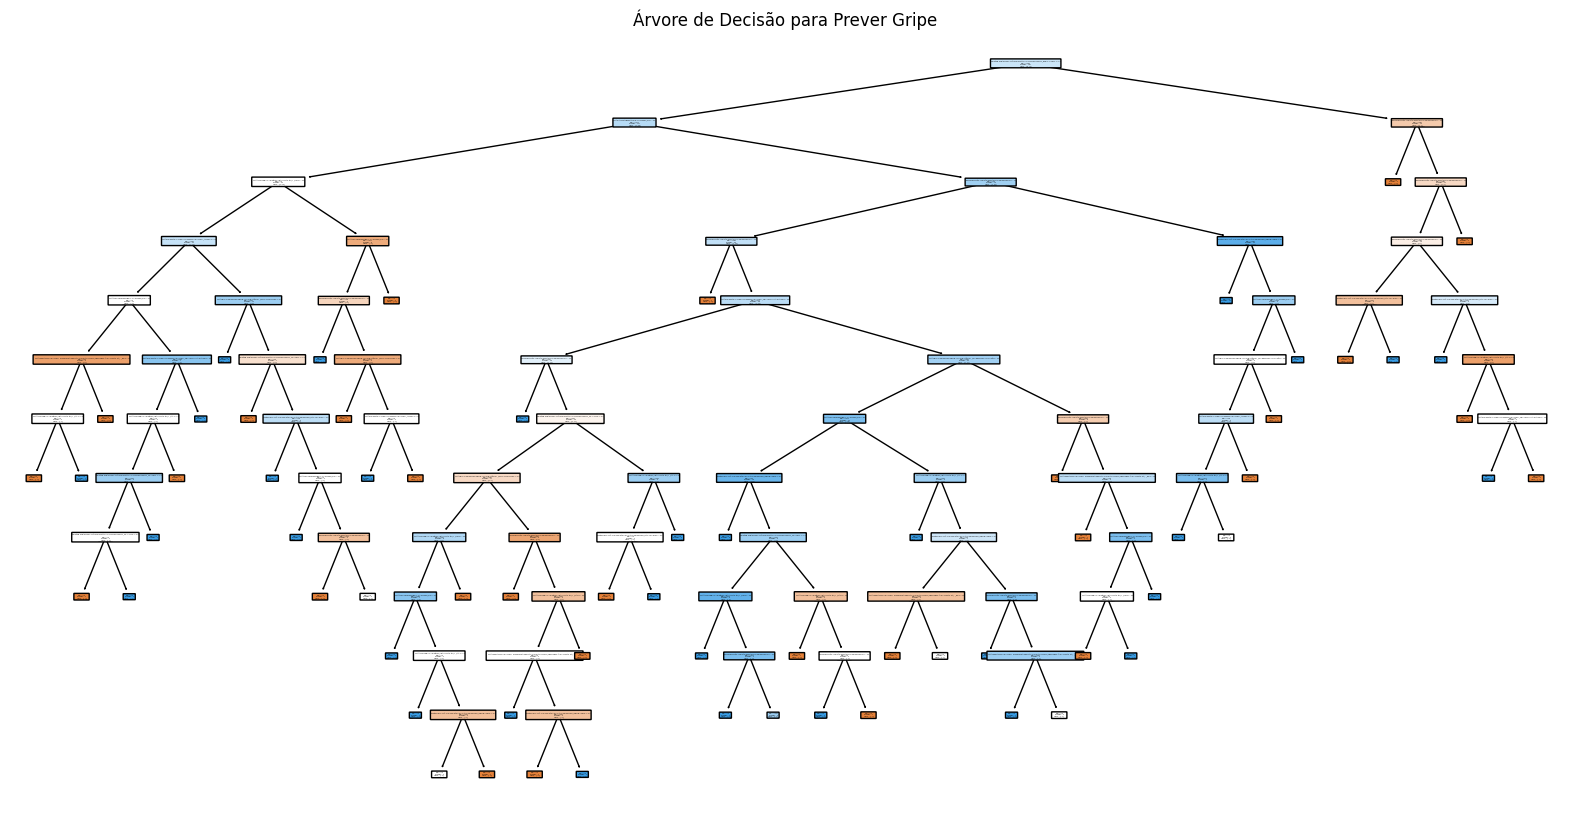

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=feature_cols, class_names=['Não Gripado', 'Gripado'], rounded=True)
plt.title("Árvore de Decisão para Prever Gripe")
plt.show()